<a href="https://colab.research.google.com/github/GuilhermeFernandez/climate_resilient_pastures/blob/main/Esboco_Projeto.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Parte 1
### Objetivos:

Foco: Definir a base estática e limpar os polígonos.

Devo gerar um GeoJSON/Dataframe contendo:

1.   ID_Area: Identificador único; ✅
2.   nm_mun: município do polígono; ✅
3. classe_manejo: Categoria fixa (Extensivo, Rotacionado, SSP Nativas, SSP Exóticas);
4. geometry: Polígono da propriedade; ✅
5. area_ha: Área calculada da geometria útil. ✅
6. date_implementation: Ano em que o sistema foi implantado.
7. %_cobertura_arborea: calculada com modelo baseado em CBERS-4A, imagens de 2025 (se possível), máscara de recorte com buffer de 1pixel 8x8. ✅ (parcialmente)










### Importando Bibliotecas necessárias

In [60]:
!pip install geobr
!pip install git+https://github.com/cgarrard/osgeopy-code.git#subdirectory=ospybook
!pip install pyMannKendall
import sys, os, geobr
import geopandas as gpd
import pandas as pd

  Cloning https://github.com/cgarrard/osgeopy-code.git to /tmp/pip-req-build-d4r8xrj6
  Running command git clone --filter=blob:none --quiet https://github.com/cgarrard/osgeopy-code.git /tmp/pip-req-build-d4r8xrj6
  Resolved https://github.com/cgarrard/osgeopy-code.git to commit bc85f4ec7a630b53502ee491e400057b67cdab22
  Preparing metadata (setup.py) ... done
  Created wheel for ospybook: filename=ospybook-1.0-py3-none-any.whl size=9486 sha256=654ffb61c8332022238e65bccbc6019b125b1d27dbda2a5e97b06c55a52e54fa
  Stored in directory: /tmp/pip-ephem-wheel-cache-_hb2p07w/wheels/d0/1f/99/a47b9c14da62225818ca583d918fb472dcdb58f32e4ce04bb7
Successfully built ospybook


### Definindo diretório

In [3]:
path = '/content/drive/MyDrive/Colab Notebooks/Esboco_Projeto'
files = [f for f in os.listdir(path) if f.endswith('.shp')]

### Extraindo geometrias dos shapefiles no diretório

In [5]:
gdfs = []

for file in files:
    full_path = os.path.join(path, file)
    try:
        gdf_temp = gpd.read_file(full_path)
        gdfs.append(gdf_temp)
    except Exception as e:
        print(f"Erro ao ler {file}: {e}")

if gdfs:
    gdf = pd.concat(gdfs, ignore_index=True)

    #Ajuste de Projeção para Cálculo de Área:
    if gdf.crs is None:
        gdf.set_crs(epsg=32721, inplace=True) # Assumindo UTM 21S se não tiver nada -- já que a área de estudo é no Mato Grosso
    else:
        gdf = gdf.to_crs(epsg=32721) # Convertendo para UTM 21S se estiver em outro

    #Calculo da área:
    gdf['Area_ha'] = gdf.area / 10000

    #Converte para o CRS final de saída (SIRGAS 2000 Lat/Lon):
    gdf = gdf.to_crs(epsg=4674)

    #Cria o ID para a Área de Estudo e Salva
    gdf['ID_Area'] = gdf.index + 1

    output_file = os.path.join(path, 'study_areas.geojson')
    gdf.to_file(output_file, driver='GeoJSON')
    print("Arquivo salvo com sucesso!")
else:
    print("Nenhum arquivo shapefile encontrado.")

Arquivo salvo com sucesso!


### Extraindo município das coordenadas a partir de IBGE 2024

In [6]:
municipalities = geobr.read_municipality(code_muni='MT', year=2024)
gdf_mun = gpd.sjoin(gdf, municipalities[['name_muni', 'geometry']],
                             how='left',
                             predicate='intersects')
gdf_mun = gdf_mun.drop(['index_right', 'id'], axis=1)
gdf_mun.columns = ['geometry','area_ha','ID_Area','nm_mun']

gdf_mun.to_file('study_areas.geojson', driver='GeoJSON')

### Criando Modelo Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier
import rasterio
import numpy as np
from rasterio.mask import mask

gdf_treino = gpd.read_file('/content/drive/MyDrive/Colab Notebooks/Esboco_Projeto/Treino/classificacaoSupervisionada08_12_mesclado_SEMSOMBRA.shp')
caminho_tif = '/content/drive/MyDrive/Colab Notebooks/Esboco_Projeto/Treino/PAN.tif'
coluna_classe = 'Classe'

lista_de_pixels = []
with rasterio.open(caminho_tif) as src:
  if gdf_treino.crs != src.crs:
    gdf_treino = gdf_treino.to_crs(src.crs)

  for index, row in gdf_treino.iterrows():
    geometria = [row['geometry']]
    classe_atual = row[coluna_classe]

    out_image, out_transform = mask(src, geometria, crop=True)

    num_bandas = out_image.shape[0]

    pixels = out_image.transpose(1, 2, 0).reshape(-1, num_bandas)
    pixels_validos = pixels[np.sum(pixels, axis=1) > 0]

    nomes_colunas = [f'Banda_{i+1}' for i in range(num_bandas)]
    df_temp = pd.DataFrame(pixels_validos, columns=nomes_colunas)
    df_temp['Target'] = classe_atual
    lista_de_pixels.append(df_temp)

df_treinamento = pd.concat(lista_de_pixels, ignore_index=True)

X = df_treinamento.drop(columns=['Target'])
y = df_treinamento['Target']

modelo_RF = RandomForestClassifier(random_state=42, max_depth=7)
modelo_RF.fit(X, y)

import pickle
with open('modelo_RF.pkl', 'wb') as f:
    pickle.dump(modelo_RF, f)

### Acurácia

In [ ]:
from sklearn.metrics import accuracy_score

y_pred = modelo_RF.predict(X)
accuracy = accuracy_score(y, y_pred)

print(f"Acurácia do modelo: {accuracy * 100:.2f}%")

In [ ]:
import graphviz
from yellowbrick.classifier import ConfusionMatrix, ClassificationReport
from yellowbrick.model_selection import FeatureImportances

classes = ["Árvore", "Pasto"]
visualizer = ClassificationReport(modelo_RF, classes=classes, support=True)

visualizer.fit(X, y)
visualizer.score(X, y)
visualizer.show()

### Carregando Modelo Random Forest

In [ ]:
import os
import geopandas as gpd
import ospybook as pb

with open('modelo_RF.pkl', 'rb') as f:
    cob_arborea = pickle.load(f)

### Recuperando imagens PANSHARPENING para aplicação de Modelo

In [ ]:
gdf = gpd.read_file('/content/study_areas.geojson')
gdf = gdf.to_crs(epsg=4674)

### Aplicação de Modelo

In [ ]:
gdf_model_list = []

for index, row in gdf.iterrows():
  id_area = str(int(row['ID_Area']))
  geom = row['geometry']
  area_ha = row.get('area_ha', None)
  nm_mun = row.get('nm_mun', None)
  path_pan = f'/content/drive/MyDrive/Colab Notebooks/Esboco_Projeto/{id_area}'
  if not os.path.exists(path_pan):
    print(f"Aviso: Pasta não encontrada para ID_Area {id_area}")
    continue

  files_pan = [f for f in os.listdir(path_pan) if f.endswith('.tif')]
  for file_name in files_pan:
        full_file_path = os.path.join(path_pan, file_name)
        #Trecho tirado de "Geoprocessing with Python" - Chris Garrard (pg.282)
        data = pb.stack_bands([full_file_path])
        rows, cols, bands = data.shape
        data2d = np.reshape(data, (rows * cols, bands))

        prediction = cob_arborea.predict(data2d)
        prediction = np.reshape(prediction, (rows, cols))

        mascara_fundo = np.sum(data, axis=2) == 0
        prediction[mascara_fundo] = 0


        valor_classe_arvore = 1
        pixels_validos = np.sum(~mascara_fundo)
        pixels_arvore = np.sum(prediction == valor_classe_arvore)
        if pixels_validos > 0:
            perc_cob_arborea = (pixels_arvore / pixels_validos) * 100
        else:
            perc_cob_arborea = 0

        gdf_model_list.append({
            'ID_Area': id_area,
            'geometry': geom,
            'area_ha': area_ha,
            'nm_mun': nm_mun,
            'arquivo_tif': file_name,
            'perc_cob_arborea': perc_cob_arborea
        })

gdf_final = gpd.GeoDataFrame(gdf_model_list, crs=gdf.crs)

print(f"Processamento concluído. {len(gdf_final)} imagens analisadas.")

In [ ]:
gdf_final

## Parte 2
### Objetivos:

Foco: Processamento pesado. Classificar cobertura e extrair índices para cada ano/mês dos 40 anos. A área deve ser recortada pela máscara gerada na Parte 1 para retirada de pixels com cobertura arbórea superior a 10%. Deve iterar sobre a coleção Landsat e CHIRPS e gerar um Dataframe contendo:

1.   ID_Area: Identificador único; ✅
2.   date: Ano; ✅
3. ndvi_value: Média (?) do NDVI apenas nos pixels de pasto; ✅ (por enquanto, média)
4. ndmi_value: Média (?) do NDMI; ✅ (por enquanto, média)
5. lst_value: Média (?) da temperatura de superfície;
6. precipitation_mm: Acumulado de chuva do CHIRPS para o período; ✅
7. precip_anomalies: para cada ano, True ou False. ✅


In [7]:
import ee
import json

In [11]:
#Autenticando projeto
ee.Authenticate()
ee.Initialize(project='ee-guilhermefernandez')

In [12]:
#Arquivo contendo as informações geográficas
gdf = gpd.read_file('/content/study_areas.geojson')
gdf.to_crs(epsg=4674)

,area_ha,ID_Area,nm_mun,geometry
0,165.78976,1,Nova Guarita,"POLYGON ((-55.38248 -10.21095, -55.38102 -10.2..."


In [13]:
#Anos e lista para armazenamento dos dados
years = ee.List.sequence(1986, 2025)
dados_finais = []

In [14]:
#Função para calcular precipitação acumulada anual
def calculateAnnualPrecipitation(year):
    rainfallCollection = ee.ImageCollection('UCSB-CHG/CHIRPS/DAILY').select('precipitation')
    startDateYear = ee.Date.fromYMD(year, 1, 1)
    endDateYear = ee.Date.fromYMD(year, 12, 31).advance(1, 'day')
    annualRainfall = rainfallCollection.filter(ee.Filter.date(startDateYear, endDateYear)).sum()
    rainfallMean = annualRainfall.reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=geom,
        scale=5566,
        maxPixels=1e9
    )
    return ee.Feature(None, {
        'year': year,
        'precipitation': rainfallMean.get('precipitation')
    })

In [15]:
#Transformando os dados brutos do LANDSAT
def apply_scale_factors(image):
    optical_bands = image.select('SR_B.').multiply(0.0000275).add(-0.2)
    return image.addBands(optical_bands, None, True)

#Criando máscara de nuvens e sombra:
def mask_clouds(image):
    qa = image.select('QA_PIXEL')
    # Bits 3 (nuvem) e 4 (sombra de nuvem)
    cloud_shadow_bit_mask = 1 << 4
    clouds_bit_mask = 1 << 3

    mask = qa.bitwiseAnd(cloud_shadow_bit_mask).eq(0) \
        .And(qa.bitwiseAnd(clouds_bit_mask).eq(0))

    return ee.Image(image.updateMask(mask).copyProperties(image, ["system:time_start"]))

In [16]:
#Harmonizando Landsat 5 e 7 ETM+ para OLI(8):
def prep_landsat_5_7(image):
    image = ee.Image(image)
    # L5/L7 Bandas: 1=Azul, 2=Verde, 3=Vermelho, 4=NIR, 5=SWIR1
    img_scaled = apply_scale_factors(image)
    img_masked = mask_clouds(img_scaled)

    renamed = img_masked.select(
        ['SR_B1', 'SR_B2', 'SR_B3', 'SR_B4', 'SR_B5'],
        ['Blue', 'Green', 'Red', 'NIR', 'SWIR1']
    )

    # Coeficientes de Harmonização (Roy et al., 2016):
    slopes = ee.Image.constant([0.9785, 0.9542, 0.9825, 1.0073, 1.0171])
    intercepts = ee.Image.constant([-0.0095, -0.0016, -0.0022, -0.0021, -0.0030])
    harmonized = renamed.multiply(slopes).add(intercepts)
    harmonized = harmonized.toFloat()

    return calculate_indices(ee.Image(harmonized.copyProperties(image, ["system:time_start"])))


#Renomeando as bandas de Landsat 8 e 9
def prep_landsat_8_9(image):
    # L8/L9 Bandas: 2=Azul, 3=Verde, 4=Vermelho, 5=NIR, 6=SWIR1
    img_scaled = apply_scale_factors(image)
    img_masked = mask_clouds(img_scaled)

    renamed = img_masked.select(
        ['SR_B2', 'SR_B3', 'SR_B4', 'SR_B5', 'SR_B6'],
        ['Blue', 'Green', 'Red', 'NIR', 'SWIR1']
    )

    renamed = renamed.toFloat()
    return calculate_indices(ee.Image(renamed.copyProperties(image, ["system:time_start"])))

In [17]:
#Função para calculo de índices:
def calculate_indices(image):
    ndvi = image.normalizedDifference(['NIR', 'Red']).rename('NDVI')
    ndmi = image.normalizedDifference(['NIR', 'SWIR1']).rename('NDMI')
    return image.addBands([ndvi, ndmi])

In [18]:
#Função para pegar o índice calculado e extrair a média anual
def calcular_media_anual_landsat(year):
  #Primeiro puxando as coleções e filtrando pela área da ID_Area que vai ser usada:
  l5 = ee.ImageCollection("LANDSAT/LT05/C02/T1_L2").filterBounds(geom).filterDate(ano_inicio, ano_fim).map(prep_landsat_5_7)
  l7 = ee.ImageCollection("LANDSAT/LE07/C02/T1_L2").filterBounds(geom).filterDate(ano_inicio, ano_fim).map(prep_landsat_5_7)
  l8 = ee.ImageCollection("LANDSAT/LC08/C02/T1_L2").filterBounds(geom).filterDate(ano_inicio, ano_fim).map(prep_landsat_8_9)
  l9 = ee.ImageCollection("LANDSAT/LC09/C02/T1_L2").filterBounds(geom).filterDate(ano_inicio, ano_fim).map(prep_landsat_8_9)

  # Mesclando tudo em uma única coleção harmonizada:
  landsat_harmonizada = l5.merge(l7).merge(l8).merge(l9)

  #Métricas para calculo da média:
  startDateYear = ee.Date.fromYMD(year, 1, 1)
  endDateYear = ee.Date.fromYMD(year, 12, 31).advance(1, 'day')
  colecao_ano = landsat_harmonizada.filterDate(startDateYear, endDateYear)

  imagem_media = colecao_ano.mean()

  estatisticas = imagem_media.reduceRegion(
          reducer=ee.Reducer.mean(),
          geometry=geom,
          scale=30,
          maxPixels=1e9
      )

  return ee.Feature(None, {
          'year': year,
          'NDVI_medio': estatisticas.get('NDVI'),
          'NDMI_medio': estatisticas.get('NDMI')
      })

In [19]:
#Executando funções para cada iteração em gdf (arquivo GeoJSON):

for index, row in gdf.iterrows():
  geom = ee.Geometry(row.geometry.__geo_interface__)
  id_area = row['ID_Area'] if 'ID_Area' in gdf.columns else index
  ano_inicio = '1986-01-01'
  ano_fim = '2025-12-31'

  #Chuva
  annualRainfallData = years.map(calculateAnnualPrecipitation)
  rainfallInfo = annualRainfallData.getInfo()

  #Média anual dos índices
  dados_anuais_landsat = years.map(calcular_media_anual_landsat)
  landsat_info = dados_anuais_landsat.getInfo()

  #Armazenando em uma lista
  for rain_feat, land_feat in zip(rainfallInfo, landsat_info):
        props_rain = rain_feat['properties']
        props_land = land_feat['properties']
        if props_land.get('NDVI_medio') is not None:
          dados_finais.append({
                'ID_Area': id_area,
                'year': props_land['year'],
                'precipitation': props_rain.get('precipitation'),
                'NDVI': props_land.get('NDVI_medio'),
                'NDMI': props_land.get('NDMI_medio')
            })

In [20]:
#Passando para um dataframe:

df_metricas = pd.DataFrame(dados_finais)
df_metricas = df_metricas.sort_values(by=['ID_Area', 'year']).reset_index(drop=True)

In [21]:
#Calcula a média e std de precipitação para cada ID_Area, categoriza anos anômalos:

mean_precip = df_metricas.groupby('ID_Area')['precipitation'].transform('mean')
std_precip = df_metricas.groupby('ID_Area')['precipitation'].transform('std')

df_metricas['precip_anomalies'] = df_metricas['precipitation'] < (mean_precip - std_precip)

In [26]:
#Verificando convergência entre anomalies de precipitação e eventos de El Niño:

df_metricas['ElNino_anomalies'] = (df_metricas['precip_anomalies']) & (df_metricas['year'].isin([1986, 1987, 1988, 1991, 1992, 1994, 1995, 1997, 1998, 2002, 2003, 2004, 2005, 2006, 2007, 2009, 2010, 2014, 2015, 2016, 2018, 2019, 2023, 2024]))

In [36]:
#Display:

print(f'O número de anomalias (negativas) na precipitação para cada área é \n {df_metricas.groupby(['ID_Area'])['precip_anomalies'].sum()}')

print(f'O número de convergências entre anomalies e El Niño é \n {df_metricas.groupby(['ID_Area'])['ElNino_anomalies'].sum()}')

O número de anomalias (negativas) na precipitação para cada área é 
 ID_Area
1    5
Name: precip_anomalies, dtype: int64
O número de convergências entre anomalies e El Niño é 
 ID_Area
1    5
Name: ElNino_anomalies, dtype: int64


In [37]:
#Salvar em CSV:
df_metricas.to_csv('metricas.csv', index=False)

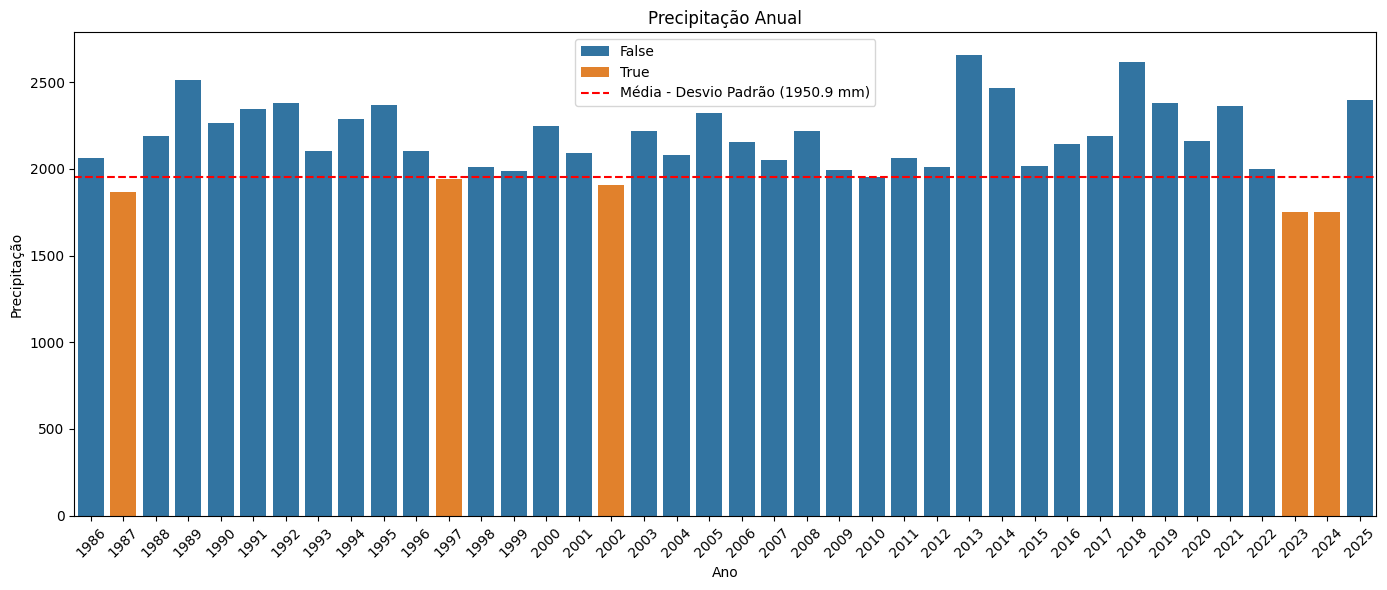

In [39]:
import seaborn as sns
import matplotlib.pyplot as plt

#Gráfico para visualizar anos considerados anômalos (abaixo da média - std):

N_AREA = 1
mean_precipitation_std = df_metricas[df_metricas['ID_Area'] == N_AREA]['precipitation'].mean() - df_metricas[df_metricas['ID_Area'] == N_AREA]['precipitation'].std()

plt.figure(figsize=(14, 6))
p = sns.barplot(x='year', y='precipitation', data=df_metricas[df_metricas['ID_Area'] == N_AREA], hue='ElNino_anomalies')
plt.axhline(y= mean_precipitation_std, color='red', linestyle='dashed', label=f'Média - Desvio Padrão ({mean_precipitation_std:.1f} mm)')
plt.xticks(rotation=45)
plt.title('Precipitação Anual')
plt.xlabel('Ano')
plt.ylabel('Precipitação')
plt.legend()

plt.tight_layout()
plt.show()

<Axes: xlabel='precip_anomalies', ylabel='count'>

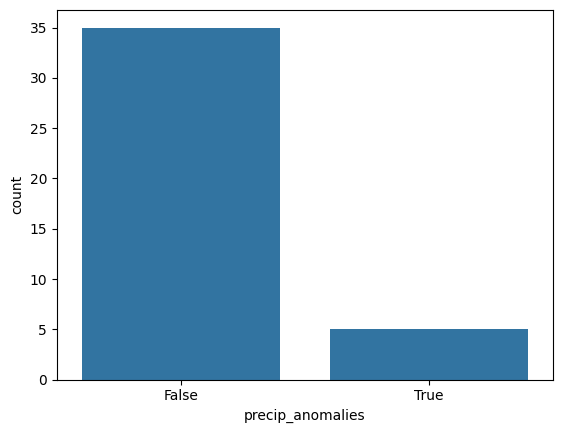

In [ ]:
#Countplot mostrando a divergência entre anômalo e "normal" para a área selecionada:

N_AREA = 1
mean_precipitation_std = df_metricas[df_metricas['ID_Area'] == N_AREA]['precipitation'].mean() - df_metricas[df_metricas['ID_Area'] == N_AREA]['precipitation'].std()

sns.countplot(data=df_metricas[df_metricas['ID_Area'] == N_AREA], x='precip_anomalies', legend='full')

<Axes: xlabel='year', ylabel='NDVI'>

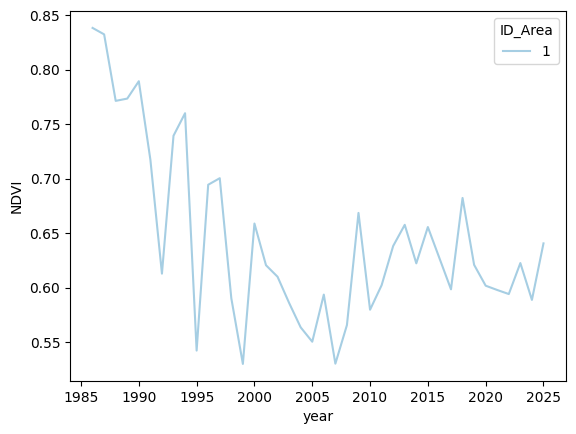

In [41]:
#Série história NDVI:

sns.lineplot(x='year', y='NDVI', data=df_metricas[df_metricas['ID_Area'] == N_AREA], palette='Paired', hue='ID_Area')

<Axes: xlabel='year', ylabel='NDMI'>

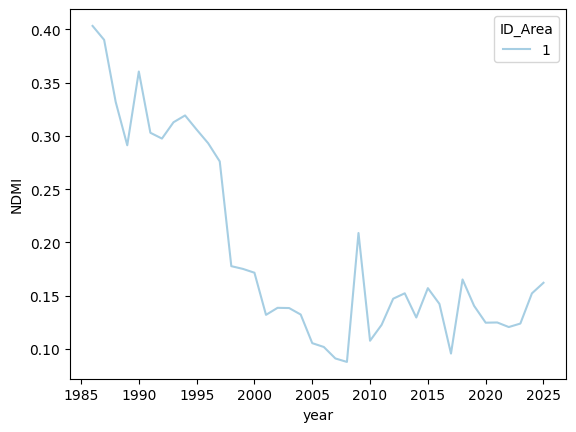

In [ ]:
#Série história NDMI:

sns.lineplot(x='year', y='NDMI', data=df_metricas[df_metricas['ID_Area'] == N_AREA], palette='Paired', hue='ID_Area')

## Parte 3
### Objetivos:

Foco: Transformar dados em resultados.

Deve ler o Dataframe do Script 2 e gerar um Dataframe de Resultados contendo:


1.   ID_Area: Identificador único; ✅
2.   Index: Coluna indicando qual índice (NDVI, NDMI ou LST)✅
3. Senslope_trend_pre: Valor da inclinação da tendência ao longo da série;
4. Senslope_trend_post: Valor da inclinação da tendência ao longo da série após implementação, se houver;
5. trend_significance_pre: Valor-p do teste Mann-Kendall;
6. trend_significance_post: Valor-p do teste Mann-Kendall;
7. z_score_drought: O desvio padrão do índice durante os anos de anomalia climática (secas identificadas = precip_anomalies == True) ✅
8. comparative_resilience: Rótulo final (Brightspot, Hotspot ou Neutro) baseado na comparação com vizinhos em períodos de anomalia climática (secas identificadas = precip_anomalies == True) ✅





In [43]:
df_metricas = pd.read_csv('/content/metricas.csv')

In [45]:
df_analise = df_metricas.drop(columns="ElNino_anomalies")

In [46]:
df_analise.head()

,ID_Area,year,precipitation,NDVI,NDMI,precip_anomalies
0,1,1986,2060.799708,0.838497,0.403341,False
1,1,1987,1864.352250,0.832574,0.390249,True
2,1,1988,2191.557225,0.771499,0.331918,False
3,1,1989,2514.162230,0.773596,0.291234,False
4,1,1990,2266.888193,0.789552,0.360536,False


In [56]:
#Z-Score, depois extrair os anos em que tem anomalia e avaliar:
from scipy.stats import zscore
import numpy as np

df_analise['zscore_ndvi'] = df_analise.groupby('ID_Area')[['NDVI']].transform(zscore)

In [57]:
#Brightspots e Hotspots, depois extrair os anos em que tem anomalia e avaliar:

df_analise['best_NDVI'] = df_analise.groupby('year')['NDVI'].transform('quantile', q=0.8) # o código agrupa os NDVIs por ano e calcula o quartil 0.8 (80%)
df_analise['worst_NDVI'] = df_analise.groupby('year')['NDVI'].transform('quantile', q=0.2) # o código agrupa os NDVIs por ano e calcula o quartil 0.2 (20%)

conditions = [
    df_analise['NDVI'] >= df_analise['best_NDVI'], #maior que 80% dos NDVIs? Brightspot
    df_analise['NDVI'] <= df_analise['worst_NDVI'] #menor que 20% dos NDVIs? Hotspots
]
choices = ['Brightspot', 'Hotspot']

df_analise['Classificacao'] = np.select(conditions, choices, default='Neutro') #default para que os valores intermediários sejam classificados como 'Neutro'

In [65]:
import pymannkendall as mk

#Calculando slope e p_value:
df_analise['trend_slope'] = df_analise.groupby('ID_Area')['NDVI'].transform(lambda x: mk.sens_slope(x).slope)

df_analise['p_value_trend'] = df_analise.groupby('ID_Area')['NDVI'].transform(lambda x: mk.original_test(x).p)


#Aqui dá para filtrar por anos e brightspots daqueles anos:
df_brightspots_seca = df_analise.query('precip_anomalies == True and Classificacao == "Brightspot"')

In [66]:
df_brightspots_seca

,ID_Area,year,precipitation,NDVI,NDMI,precip_anomalies,zscore_ndvi,best_NDVI,worst_NDVI,Classificacao,trend_slope,p_value_trend
1,1,1987,1864.352250,0.832574,0.390249,True,2.370558,0.832574,0.832574,Brightspot,-0.003821,0.008174
11,1,1997,1938.349090,0.700486,0.276069,True,0.707871,0.700486,0.700486,Brightspot,-0.003821,0.008174
16,1,2002,1904.208280,0.609970,0.138590,True,-0.431523,0.609970,0.609970,Brightspot,-0.003821,0.008174
37,1,2023,1750.879165,0.622558,0.123827,True,-0.273065,0.622558,0.622558,Brightspot,-0.003821,0.008174
38,1,2024,1748.503102,0.588714,0.152165,True,-0.699083,0.588714,0.588714,Brightspot,-0.003821,0.008174


In [59]:
df_analise.to_csv('analise.csv', index=False)